<a href="https://colab.research.google.com/github/yrhutu21/Computer_Vision/blob/main/Convolution_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
ar = np.array([3,5,6,2,1,5])

In [3]:
np.convolve(ar, [1,2,3]) # (3,2,1)

array([ 3, 11, 25, 29, 23, 13, 13, 15])

Covolution On the Images from load_digits

In [4]:
from sklearn.datasets import load_digits

In [5]:
dt = load_digits(n_class=3)

In [6]:
dt.keys()

dict_keys(['data', 'target', 'frame', 'feature_names', 'target_names', 'images', 'DESCR'])

In [7]:
dt.images[0]

array([[ 0.,  0.,  5., 13.,  9.,  1.,  0.,  0.],
       [ 0.,  0., 13., 15., 10., 15.,  5.,  0.],
       [ 0.,  3., 15.,  2.,  0., 11.,  8.,  0.],
       [ 0.,  4., 12.,  0.,  0.,  8.,  8.,  0.],
       [ 0.,  5.,  8.,  0.,  0.,  9.,  8.,  0.],
       [ 0.,  4., 11.,  0.,  1., 12.,  7.,  0.],
       [ 0.,  2., 14.,  5., 10., 12.,  0.,  0.],
       [ 0.,  0.,  6., 13., 10.,  0.,  0.,  0.]])

In [ ]:
# dt.target

In [8]:
dt.images.shape


(537, 8, 8)

In [9]:
X = dt.images
Y = dt.target

In [10]:
X = X.reshape(537,1,8,8)

In [11]:
import torch
import torch.nn as nn
from torch.optim import Adam

In [12]:
X = torch.FloatTensor(X)
Y = torch.LongTensor(Y)

In [13]:
X.shape

torch.Size([537, 1, 8, 8])

In [14]:
model = nn.Sequential(
    nn.Conv2d(1, 32, kernel_size=3, stride=1, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2, stride=2),
    nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2, stride=2),
    nn.Flatten(),
    nn.Linear(64*2*2, 128),
    nn.ReLU(),
    nn.Linear(128, 3)
)

In [15]:
loss = nn.CrossEntropyLoss()
opt = Adam(model.parameters(), lr=0.001)

In [16]:
c=0
for epoch in range(100):
    c=c+1
    opt.zero_grad()
    yp = model(X)
    ls = loss(yp, Y)
    ls.backward()
    opt.step()
    if c%10==0:
      print(ls.item())

0.20634375512599945
0.031087910756468773
0.007873421534895897
0.0028812396340072155
0.001495041069574654
0.0010395775316283107
0.0008070419426076114
0.0006699377554468811
0.0005755533929914236
0.0005020142998546362


 Prediction on new data

In [17]:
newx = X[112].reshape(1,1,8,8)

In [18]:
newx.shape

torch.Size([1, 1, 8, 8])

In [19]:
Yp = model(newx)

In [20]:
Yp

tensor([[-2.2509,  5.9266, -2.3348]], grad_fn=<AddmmBackward0>)

In [21]:
sx = torch.softmax(Yp, dim=1)

In [22]:
torch.argmax(sx, dim=1)

tensor([1])

Using Batches


In [34]:
from torch.utils.data import DataLoader
import pandas as pd
import torch.optim as optim

In [35]:
X_flat = X.reshape(537, -1)
df = pd.DataFrame(X_flat)

In [36]:
df['Y'] = Y

In [37]:
data = torch.tensor(df.to_numpy())

In [63]:
model = nn.Sequential(
    nn.Conv2d(1, 32, kernel_size=3, stride=1, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2, stride=2),
    nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2, stride=2),
    nn.Flatten(),
    nn.Linear(64*2*2, 128),
    nn.ReLU(),
    nn.Linear(128, 3)
)

In [64]:
lossfn = nn.CrossEntropyLoss()
batchSgd = optim.Adam(model.parameters(), lr=0.01)

In [65]:
batches = DataLoader(data, batch_size=10, shuffle=True)

In [66]:
model(X)

tensor([[-0.1274, -0.3614, -0.4378],
        [-0.0446, -0.5255, -0.8050],
        [-0.0084, -0.2541, -0.6406],
        ...,
        [ 0.1436, -0.6844, -0.9674],
        [-0.0390, -0.7189, -0.9336],
        [-0.2063, -0.4334, -0.6311]], grad_fn=<AddmmBackward0>)

In [67]:
#pip install opencv-python

In [42]:
import cv2

In [68]:
ar = cv2.imread('golden-number-1-png.webp')

In [69]:
ar.shape

(1920, 1574, 3)

In [70]:
grar = cv2.cvtColor(ar, cv2.COLOR_BGR2GRAY) if len(ar.shape) == 3 else ar

In [71]:
rszar = cv2.resize(grar, (8, 8))

In [72]:
far = rszar.reshape(1, 64)

In [73]:
far

array([[  0,   0,   0,   0,   0, 188, 255, 255,   0,   0,   0, 199, 193,
        187, 249, 249,   0,   0, 218, 160, 166, 178, 250, 250,   0,   0,
          0, 249, 205, 169, 237, 237,   0,   0,   0, 249, 178, 154, 243,
        243,   0,   0,   0, 249, 195, 144, 255, 255,   0,   0,   0, 249,
        211, 176, 255, 255,   0,   0,   0,   0, 207, 237, 226, 226]],
      dtype=uint8)

In [74]:
fimg = torch.FloatTensor(far)

In [76]:
fimg = fimg.view(1, 1, 8, 8)

In [77]:
model(fimg)

tensor([[  4.3322, -13.3942, -15.0863]], grad_fn=<AddmmBackward0>)

In [78]:
sfx = torch.softmax(model(fimg), dim=1)

In [79]:
torch.argmax(sfx, dim=1)

tensor([0])

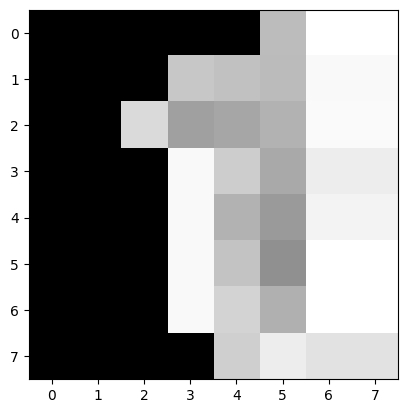

In [80]:
import matplotlib.pyplot as plt
plt.imshow(rszar, cmap='gray')
plt.show()